<a href="https://www.kaggle.com/code/sonawanelalitsunil/car-price-prediction-using-ml-99?scriptVersionId=224198846" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-price/car_price_dataset.csv


## Project Title:
### "Predictive Modeling for Car Price Estimation Using Machine Learning"

**Project Description:
In today's automotive market, determining the fair market value of a car is crucial for buyers, sellers, and dealers. This project aims to develop a machine learning-based car price prediction system that accurately estimates a vehicle's price based on key attributes such as brand, model, year, mileage, fuel type, engine capacity, transmission, location, and market trends.**

### Key Objectives:

Data Collection & Preprocessing:

Gather car price datasets from reliable sources (e.g., Kaggle, online car marketplaces, dealerships).

Clean, transform, and handle missing values to prepare structured data for modeling.

Feature Engineering & Selection:

Identify the most important features influencing car prices using correlation analysis and feature selection techniques.

Engineer new features such as age of the car, depreciation rate, and demand-supply indicators.

### Model Development:

Implement regression models (Linear Regression, Decision Trees, Random Forest, XGBoost, LightGBM) for price prediction.

Tune hyperparameters and optimize models using cross-validation and grid search/random search.

Compare models using performance metrics such as RMSE, MAE, and R² score.

### Deployment & Visualization:

Develop a web application or dashboard (using Streamlit, Flask, or FastAPI) to allow users to input car details and get instant price predictions.

Use interactive visualizations (Matplotlib, Seaborn, Plotly) to showcase price trends, feature importance, and market insights.

### Business Impact & Applications:

Help buyers and sellers make informed pricing decisions.

Assist car dealerships in setting competitive pricing strategies.

Provide insights into market trends, depreciation rates, and demand patterns.

## Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/car-price/car_price_dataset.csv")

In [4]:
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [5]:
df.tail()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084
9999,Volkswagen,Tiguan,2001,2.1,Diesel,Manual,157882,3,3,3342


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [7]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


In [8]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [10]:
df.corr

<bound method DataFrame.corr of            Brand     Model  Year  Engine_Size Fuel_Type    Transmission  \
0            Kia       Rio  2020          4.2    Diesel          Manual   
1      Chevrolet    Malibu  2012          2.0    Hybrid       Automatic   
2       Mercedes       GLA  2020          4.2    Diesel       Automatic   
3           Audi        Q5  2023          2.0  Electric          Manual   
4     Volkswagen      Golf  2003          2.6    Hybrid  Semi-Automatic   
...          ...       ...   ...          ...       ...             ...   
9995         Kia    Optima  2004          3.7    Diesel  Semi-Automatic   
9996   Chevrolet    Impala  2002          1.4  Electric       Automatic   
9997         BMW  3 Series  2010          3.0    Petrol       Automatic   
9998        Ford  Explorer  2002          1.4    Hybrid       Automatic   
9999  Volkswagen    Tiguan  2001          2.1    Diesel          Manual   

      Mileage  Doors  Owner_Count  Price  
0      289944      3    

In [11]:
df.columns

Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='object')

## Visulization 

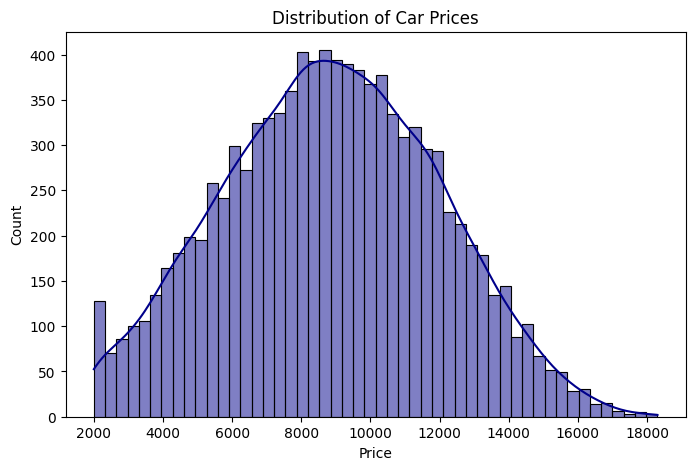

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=50, kde=True, color='darkblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

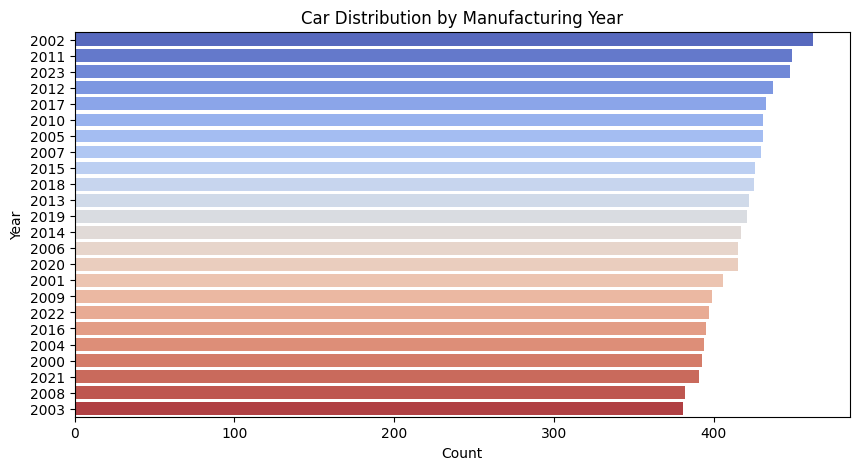

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(y=df['Year'], order=df['Year'].value_counts().index, palette='coolwarm')
plt.title('Car Distribution by Manufacturing Year')
plt.xlabel('Count')
plt.ylabel('Year')
plt.show()

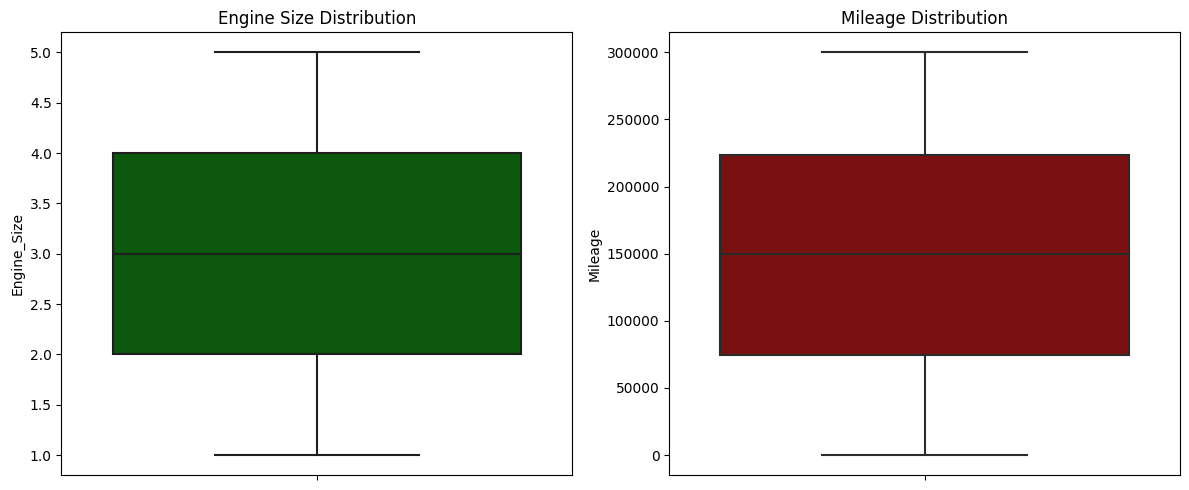

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['Engine_Size'], ax=axes[0], color='darkgreen')
axes[0].set_title('Engine Size Distribution')

sns.boxplot(y=df['Mileage'], ax=axes[1], color='darkred')
axes[1].set_title('Mileage Distribution')

plt.tight_layout()
plt.show()

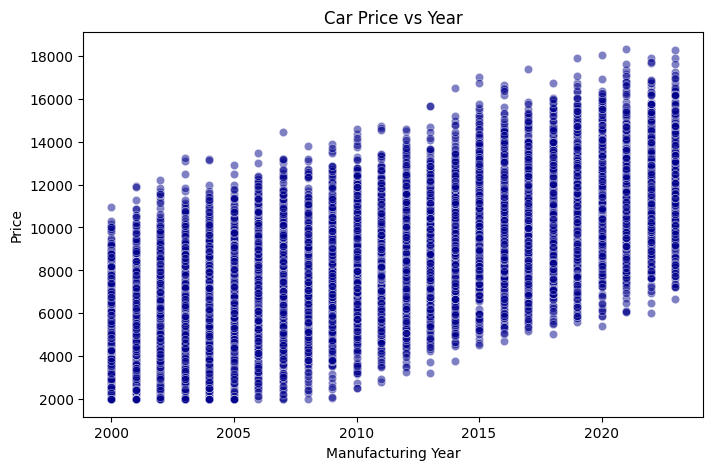

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Year'], y=df['Price'], alpha=0.5, color='darkblue')
plt.title('Car Price vs Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price')
plt.show()

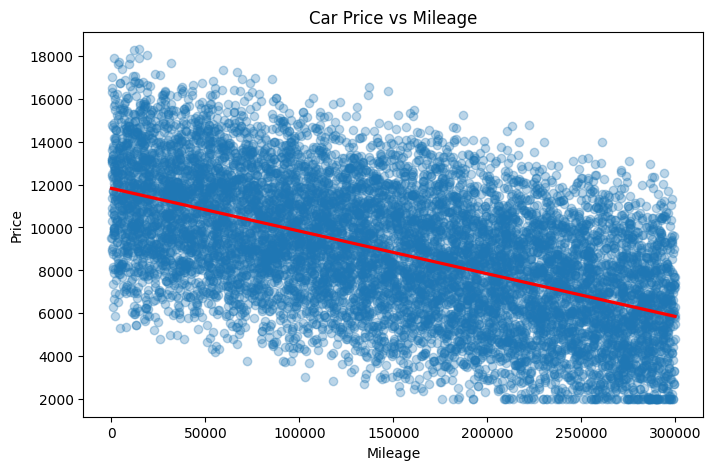

In [16]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['Mileage'], y=df['Price'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Car Price vs Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

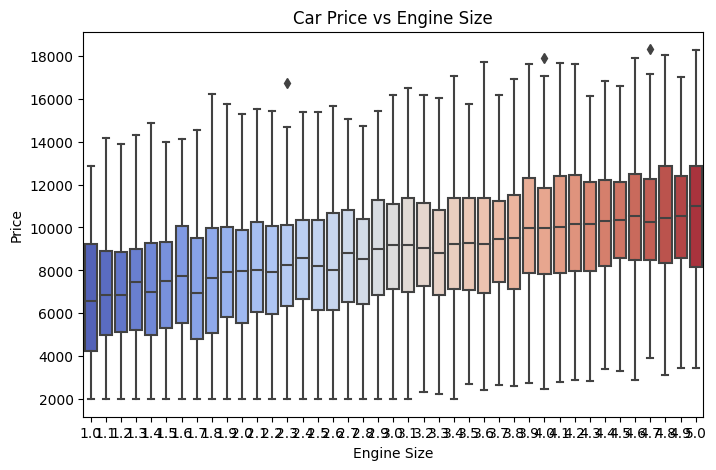

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Engine_Size'], y=df['Price'], palette='coolwarm')
plt.title('Car Price vs Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

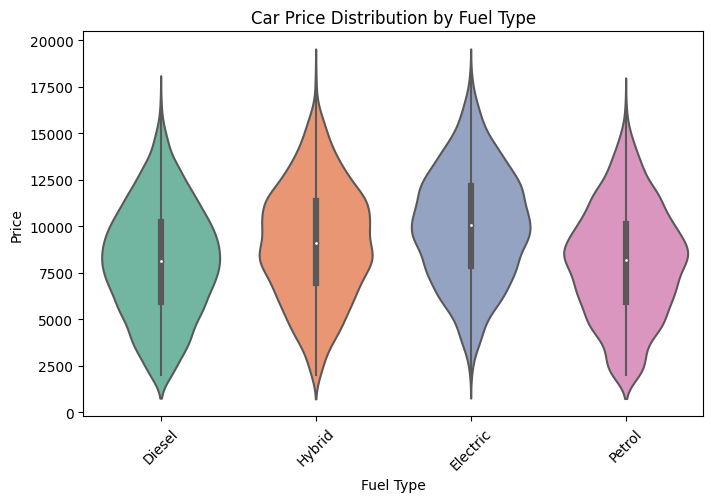

In [18]:
plt.figure(figsize=(8, 5))
sns.violinplot(x=df['Fuel_Type'], y=df['Price'], palette='Set2')
plt.title('Car Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

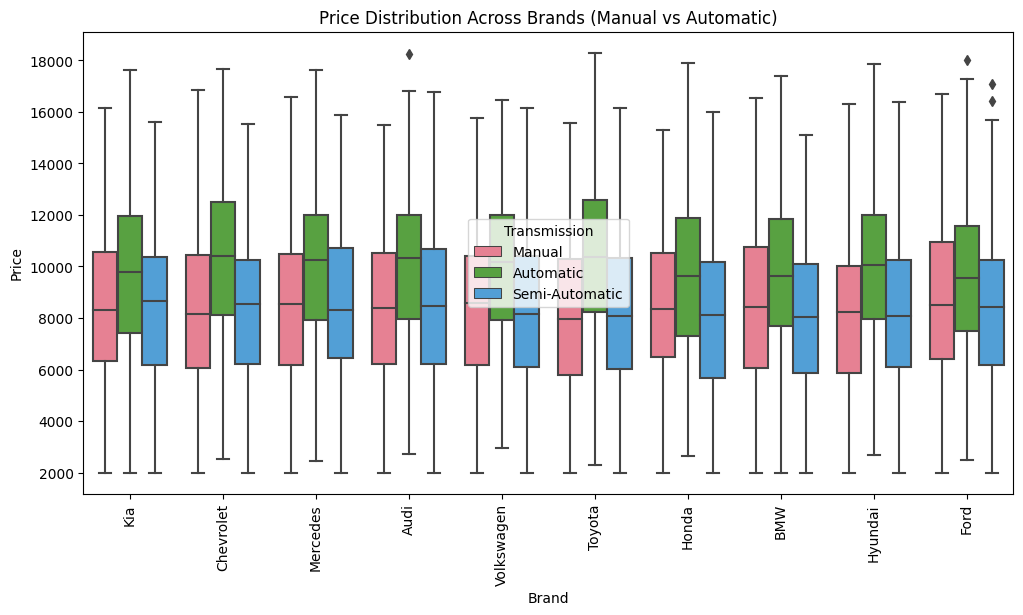

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Brand'], y=df['Price'], hue=df['Transmission'], palette='husl')
plt.title('Price Distribution Across Brands (Manual vs Automatic)')
plt.xticks(rotation=90)
plt.show()

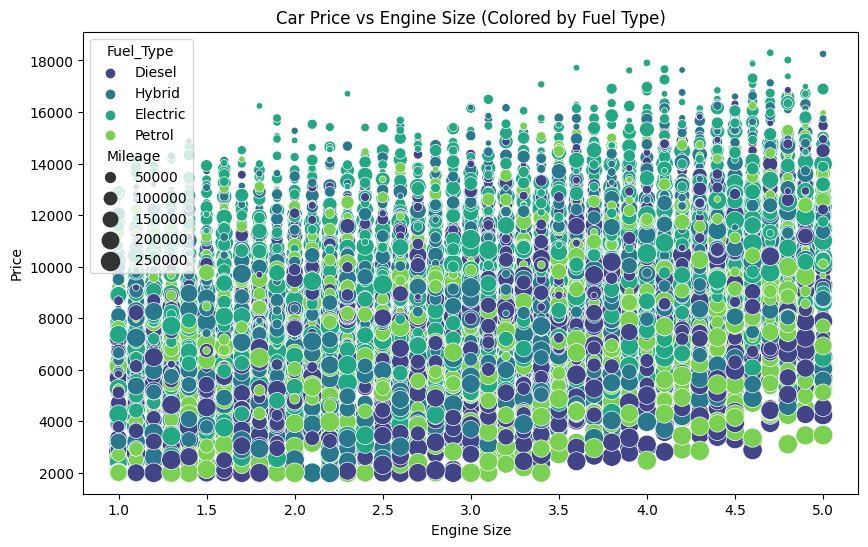

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Engine_Size'], y=df['Price'], hue=df['Fuel_Type'], size=df['Mileage'], sizes=(20, 200), palette='viridis')
plt.title('Car Price vs Engine Size (Colored by Fuel Type)')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

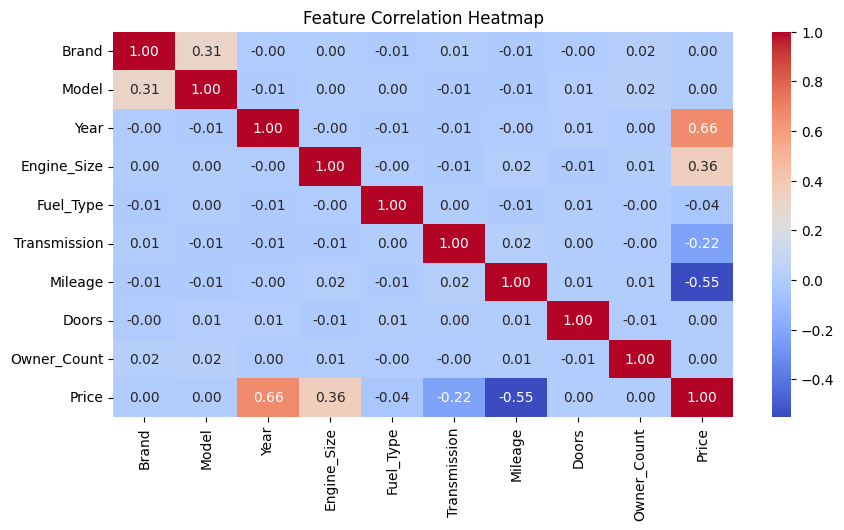

In [21]:
df_encoded = df.copy()
categorical_cols = ['Brand', 'Model', 'Fuel_Type', 'Transmission']
df_encoded[categorical_cols] = df_encoded[categorical_cols].astype('category').apply(lambda x: x.cat.codes)
plt.figure(figsize=(10, 5))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Feature Engineering

In [22]:
df["Engine_Size"].value_counts()

Engine_Size
3.7    273
4.4    271
3.6    267
2.5    266
1.5    265
4.0    263
4.6    262
2.8    262
1.3    261
2.2    259
2.6    259
1.4    259
1.6    258
2.0    258
4.1    257
3.5    256
3.1    254
3.3    254
2.9    253
4.7    253
3.8    253
1.2    251
2.7    250
4.5    250
1.8    249
3.2    249
4.9    247
1.7    246
3.4    243
4.3    242
2.4    240
3.9    236
3.0    236
2.1    234
4.2    232
1.9    232
4.8    231
1.1    230
2.3    223
1.0    113
5.0    103
Name: count, dtype: int64

In [23]:
df["Engine_Size_Group"] = pd.cut(df["Engine_Size"], bins=3, labels=["Small", "Medium", "Large"])
df["Mileage_Group"] = pd.cut(df["Mileage"], bins=3, labels=["Low", "Medium", "High"])
df["Year_of_Registration_Group"] = pd.cut(df["Year"], bins=3, labels=["2000s", "2010s", "2020s"])

In [24]:
def grab_col_names(dataframe, cat_th=10, car_th=31):
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]

    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)} -> {cat_cols}')
    print(f'num_cols: {len(num_cols)} -> {num_cols}')
    print(f'cat_but_car: {len(cat_but_car)} -> {cat_but_car}')
    print(f'num_but_cat: {len(num_but_cat)} -> {num_but_cat}')

    return cat_cols, num_cols, cat_but_car, num_but_cat


In [25]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 10000
Variables: 13
cat_cols: 9 -> ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Doors', 'Owner_Count', 'Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']
num_cols: 4 -> ['Year', 'Engine_Size', 'Mileage', 'Price']
cat_but_car: 0 -> []
num_but_cat: 5 -> ['Doors', 'Owner_Count', 'Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']


In [26]:
cat_cols

['Brand',
 'Model',
 'Fuel_Type',
 'Transmission',
 'Doors',
 'Owner_Count',
 'Engine_Size_Group',
 'Mileage_Group',
 'Year_of_Registration_Group']

In [27]:
num_cols

['Year', 'Engine_Size', 'Mileage', 'Price']

In [28]:
cat_but_car

[]

In [29]:
num_but_cat

['Doors',
 'Owner_Count',
 'Engine_Size_Group',
 'Mileage_Group',
 'Year_of_Registration_Group']

In [30]:
df["Model"].nunique()

30

In [31]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),"Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))

In [32]:
for col in cat_cols:
    cat_summary(df, col, plot=True)

            Brand  Ratio
Brand                   
Ford         1048  10.48
Audi         1038  10.38
Volkswagen   1020  10.20
Honda        1009  10.09
Chevrolet    1003  10.03
BMW           999   9.99
Hyundai       995   9.95
Kia           976   9.76
Toyota        970   9.70
Mercedes      942   9.42
          Model  Ratio
Model                 
Accord      365   3.65
Fiesta      363   3.63
Impala      355   3.55
5 Series    353   3.53
Tiguan      352   3.52
Focus       351   3.51
Q5          350   3.50
A4          350   3.50
Elantra     347   3.47
Golf        339   3.39
A3          338   3.38
Optima      336   3.36
Civic       336   3.36
3 Series    335   3.35
Explorer    334   3.34
Malibu      333   3.33
Tucson      329   3.29
Passat      329   3.29
Rio         327   3.27
Corolla     325   3.25
RAV4        324   3.24
Camry       321   3.21
E-Class     321   3.21
Sonata      319   3.19
Equinox     315   3.15
GLA         315   3.15
Sportage    313   3.13
X5          311   3.11
CR-V      

In [33]:
def num_summary(dataframe, col_name, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[col_name].describe(quantiles).T)

    if plot:
        sns.histplot(data=dataframe, x=col_name, bins=20, kde=True, color="blue")
        plt.xticks(rotation=45)
        plt.show(block=True)

count    10000.000000
mean      2011.543700
std          6.897699
min       2000.000000
5%        2001.000000
10%       2002.000000
20%       2004.000000
30%       2007.000000
40%       2009.000000
50%       2012.000000
60%       2014.000000
70%       2016.000000
80%       2019.000000
90%       2021.000000
95%       2022.000000
99%       2023.000000
max       2023.000000
Name: Year, dtype: float64


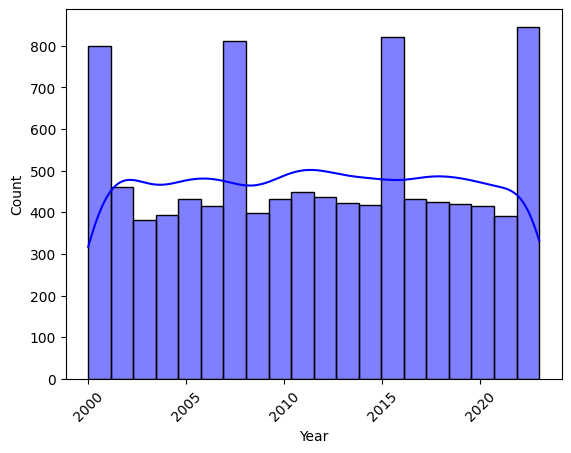

count    10000.000000
mean         3.000560
std          1.149324
min          1.000000
5%           1.200000
10%          1.400000
20%          1.800000
30%          2.200000
40%          2.600000
50%          3.000000
60%          3.400000
70%          3.800000
80%          4.200000
90%          4.600000
95%          4.800000
99%          5.000000
max          5.000000
Name: Engine_Size, dtype: float64


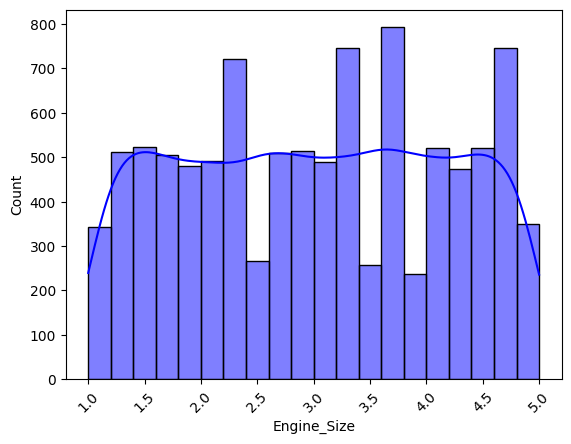

count     10000.000000
mean     149239.111800
std       86322.348957
min          25.000000
5%        14336.200000
10%       29586.500000
20%       59307.000000
30%       89633.600000
40%      119878.200000
50%      149587.000000
60%      179242.400000
70%      208518.000000
80%      238265.600000
90%      269373.400000
95%      284443.700000
99%      296474.030000
max      299947.000000
Name: Mileage, dtype: float64


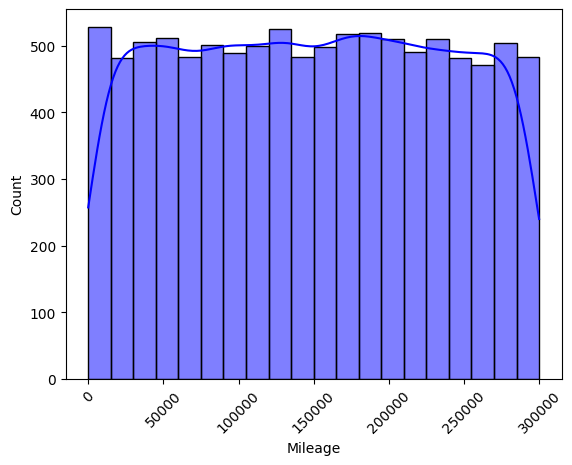

count    10000.00000
mean      8852.96440
std       3112.59681
min       2000.00000
5%        3655.00000
10%       4672.40000
20%       6067.40000
30%       7127.70000
40%       8038.00000
50%       8858.50000
60%       9701.40000
70%      10577.00000
80%      11602.60000
90%      12945.30000
95%      13981.05000
99%      15745.08000
max      18301.00000
Name: Price, dtype: float64


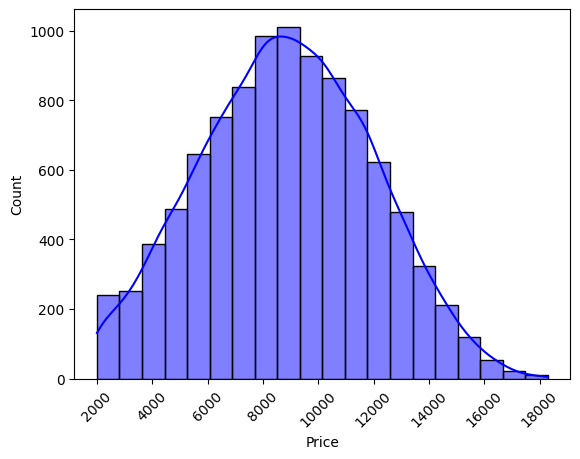

In [34]:
for col in num_cols:
    num_summary(df, col, plot=True)

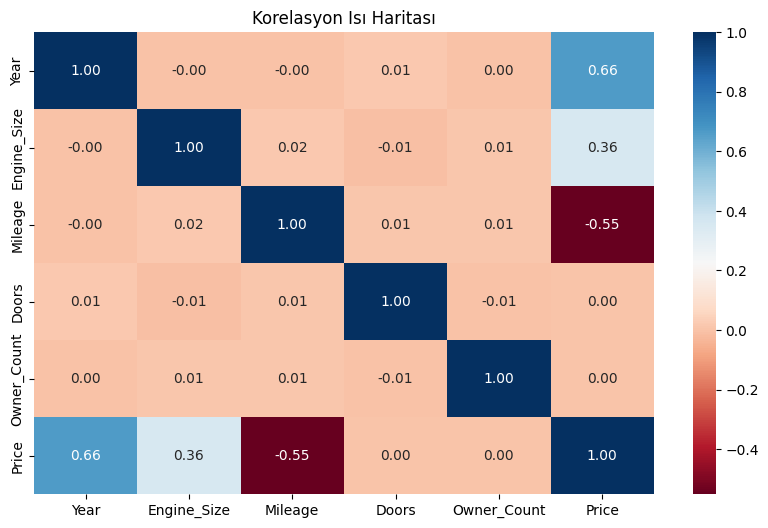

[]

In [35]:
def high_correlated_cols2(dataframe, plot=False, corr_th=0.70):
    # Sadece sayısal sütunları seçelim
    numeric_df = dataframe.select_dtypes(include=[np.number])

    # Korelasyon matrisi oluştur
    corr = numeric_df.corr()
    cor_matrix = corr.abs()

    # Üst üçgen matrisini seç (gereksiz tekrarları kaldırmak için)
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))

    # Korelasyonu eşikten yüksek olan sütun çiftlerini seçelim
    high_corrs = [(col, row)
                  for col in cor_matrix.columns
                  for row in cor_matrix.index
                  if not pd.isna(upper_triangle_matrix.loc[row, col]) and abs(
            upper_triangle_matrix.loc[row, col]) > corr_th]

    if plot:
        # Isı haritasını çiz
        plt.figure(figsize=(10, 6))
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu")
        plt.title("Korelasyon Isı Haritası")
        plt.show()

    return high_corrs
high_correlated_cols2(df, plot=True)

In [36]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)

    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])

    print(missing_df, end="\n")

    if na_name:
        return na_columns
missing_values_table(df)

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


In [37]:
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ':', len(dataframe[col].value_counts()))
        print(pd.DataFrame({'COUNT': dataframe[col].value_counts(),
                            'RATIO': dataframe[col].value_counts() / len(dataframe),
                            'TARGET_MEAN': dataframe.groupby(col)[target].mean()}), end='\n\n\n')

In [38]:
rare_analyser(df, "Price", cat_cols)

Brand : 10
            COUNT   RATIO  TARGET_MEAN
Brand                                 
Audi         1038  0.1038  8929.373796
BMW           999  0.0999  8704.068068
Chevrolet    1003  0.1003  9015.683948
Ford         1048  0.1048  8852.570611
Honda        1009  0.1009  8665.596630
Hyundai       995  0.0995  8778.279397
Kia           976  0.0976  8880.086066
Mercedes      942  0.0942  8980.087049
Toyota        970  0.0970  8798.184536
Volkswagen   1020  0.1020  8928.377451


Model : 30
          COUNT   RATIO  TARGET_MEAN
Model                               
3 Series    335  0.0335  8854.752239
5 Series    353  0.0353  8669.218130
A3          338  0.0338  8912.316568
A4          350  0.0350  8919.962857
Accord      365  0.0365  8743.761644
C-Class     306  0.0306  8921.660131
CR-V        308  0.0308  8734.714286
Camry       321  0.0321  8712.420561
Civic       336  0.0336  8517.327381
Corolla     325  0.0325  8996.618462
E-Class     321  0.0321  8967.330218
Elantra     347  0.0347  88

In [39]:
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])
    return temp_df

In [40]:
rare_encoder(df, 0.01)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price,Engine_Size_Group,Mileage_Group,Year_of_Registration_Group
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501,Large,High,2020s
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092,Small,Low,2010s
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171,Large,High,2020s
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780,Small,Medium,2020s
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867,Medium,High,2000s
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884,Large,Low,2000s
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240,Small,Medium,2000s
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866,Medium,Low,2010s
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084,Small,High,2000s


In [41]:
cat_cols, num_cols, cat_but_car,  num_but_cat = grab_col_names(df)

Observations: 10000
Variables: 13
cat_cols: 9 -> ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Doors', 'Owner_Count', 'Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']
num_cols: 4 -> ['Year', 'Engine_Size', 'Mileage', 'Price']
cat_but_car: 0 -> []
num_but_cat: 5 -> ['Doors', 'Owner_Count', 'Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']


In [42]:
num_cols = [col for col in num_cols if col not in ["Price"]]

In [43]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

In [44]:
df[num_cols] = scaler.fit_transform(df[num_cols])

In [45]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Price'])  
y = df['Price']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=17)

In [46]:
cat_cols, num_cols, cat_but_car, num_but_cat = grab_col_names(df)

Observations: 10000
Variables: 13
cat_cols: 9 -> ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Doors', 'Owner_Count', 'Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']
num_cols: 4 -> ['Year', 'Engine_Size', 'Mileage', 'Price']
cat_but_car: 0 -> []
num_but_cat: 5 -> ['Doors', 'Owner_Count', 'Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']


In [47]:
print(X_train.dtypes)

Brand                           object
Model                           object
Year                           float64
Engine_Size                    float64
Fuel_Type                       object
Transmission                    object
Mileage                        float64
Doors                            int64
Owner_Count                      int64
Engine_Size_Group             category
Mileage_Group                 category
Year_of_Registration_Group    category
dtype: object


In [48]:
print(X_train.dtypes)

Brand                           object
Model                           object
Year                           float64
Engine_Size                    float64
Fuel_Type                       object
Transmission                    object
Mileage                        float64
Doors                            int64
Owner_Count                      int64
Engine_Size_Group             category
Mileage_Group                 category
Year_of_Registration_Group    category
dtype: object


In [49]:
import pandas as pd

# Apply one-hot encoding (drop_first=True to avoid multicollinearity)
X = pd.get_dummies(X, columns=['Brand', 'Model', 'Fuel_Type', 'Transmission'], drop_first=True)

In [50]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['Engine_Size_Group', 'Mileage_Group', 'Year_of_Registration_Group']
le = LabelEncoder()

for col in label_cols:
    X[col] = le.fit_transform(X[col])  # Convert categories to integers

In [51]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

categorical_features = ['Brand', 'Model', 'Fuel_Type', 'Transmission']
numerical_features = ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count']
target_variable = 'Price'
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)
X = df[numerical_features + [col for col in df.columns if col.startswith(tuple(categorical_features))]]
y = df[target_variable]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
# Initialize models
models = [
    ('LR', LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("ElasticNet", ElasticNet()),
    ('KNN', KNeighborsRegressor()),
    ('CART', DecisionTreeRegressor()),
    ('RF', RandomForestRegressor()),
    ('GBM', GradientBoostingRegressor()),
    ("XGBoost", XGBRegressor(objective='reg:squarederror')),
    ("LightGBM", LGBMRegressor()),
    ("CatBoost", CatBoostRegressor(verbose=False))
]

# Hyperparameter Grid
param_grids = {
    'LR': {},
    'Ridge': {'alpha': [0.1, 1.0]},
    'Lasso': {'alpha': [0.1, 1.0]},
    'ElasticNet': {'alpha': [0.1, 1.0], 'l1_ratio': [0.1, 0.9]},
    'KNN': {'n_neighbors': [3, 5]},
    'CART': {'max_depth': [None, 10], 'min_samples_leaf': [1, 2]},
    'RF': {'n_estimators': [10, 50], 'max_depth': [None, 10]},
    'GBM': {'n_estimators': [10, 50], 'learning_rate': [0.01, 0.1]},
    'XGBoost': {'n_estimators': [10, 50], 'learning_rate': [0.01, 0.1]},
    'LightGBM': {'n_estimators': [10, 50], 'learning_rate': [0.01, 0.1]},
    'CatBoost': {'iterations': [10, 50], 'learning_rate': [0.01, 0.1], 'depth': [4, 6]}
}

# Initialize lists for metrics
rmse_scores, r2_scores, mae_scores, mse_scores, execution_times = [], [], [], [], []

# Train and evaluate models
for name, regressor in models:
    print(f"Training {name}...")
    start_time = time.time()

    if param_grids[name]:  # Apply GridSearchCV if hyperparameters exist
        grid_search = GridSearchCV(regressor, param_grid=param_grids[name], cv=5, n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f"Best parameters for {name}: {grid_search.best_params_}")
    else:
        best_model = regressor.fit(X_train, y_train)

    # Make predictions
    y_pred = best_model.predict(X_test)

    # Compute Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    execution_time = time.time() - start_time

    # Store Metrics
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mse_scores.append(mse)
    execution_times.append(execution_time)

    print(f"{name} - RMSE: {round(rmse, 4)}, R²: {round(r2, 4)}, MAE: {round(mae, 4)}, MSE: {round(mse, 4)}, Time: {round(execution_time, 2)} sec\n")

# Create DataFrame for comparison
results_df = pd.DataFrame({
    'Model': [name for name, _ in models],
    'RMSE': rmse_scores,
    'R² Score': r2_scores,
    'MAE': mae_scores,
    'MSE': mse_scores,
    'Execution Time (s)': execution_times
})

# Sort by RMSE (Lower is better)
results_df = results_df.sort_values(by="RMSE")
print(results_df)


Training LR...
LR - RMSE: 64.9147, R²: 0.9995, MAE: 20.0036, MSE: 4213.9233, Time: 0.05 sec

Training Ridge...
Best parameters for Ridge: {'alpha': 0.1}
Ridge - RMSE: 64.9266, R²: 0.9995, MAE: 20.0914, MSE: 4215.4698, Time: 2.26 sec

Training Lasso...
Best parameters for Lasso: {'alpha': 0.1}
Lasso - RMSE: 64.7672, R²: 0.9995, MAE: 20.0311, MSE: 4194.7915, Time: 0.21 sec

Training ElasticNet...
Best parameters for ElasticNet: {'alpha': 0.1, 'l1_ratio': 0.9}
ElasticNet - RMSE: 134.1188, R²: 0.998, MAE: 103.9059, MSE: 17987.865, Time: 0.33 sec

Training KNN...
Best parameters for KNN: {'n_neighbors': 5}
KNN - RMSE: 1610.949, R²: 0.7175, MAE: 1294.5987, MSE: 2595156.8329, Time: 0.93 sec

Training CART...
Best parameters for CART: {'max_depth': None, 'min_samples_leaf': 2}
CART - RMSE: 858.0656, R²: 0.9199, MAE: 647.0655, MSE: 736276.643, Time: 0.61 sec

Training RF...
Best parameters for RF: {'max_depth': None, 'n_estimators': 50}
RF - RMSE: 556.5572, R²: 0.9663, MAE: 449.9577, MSE: 30975

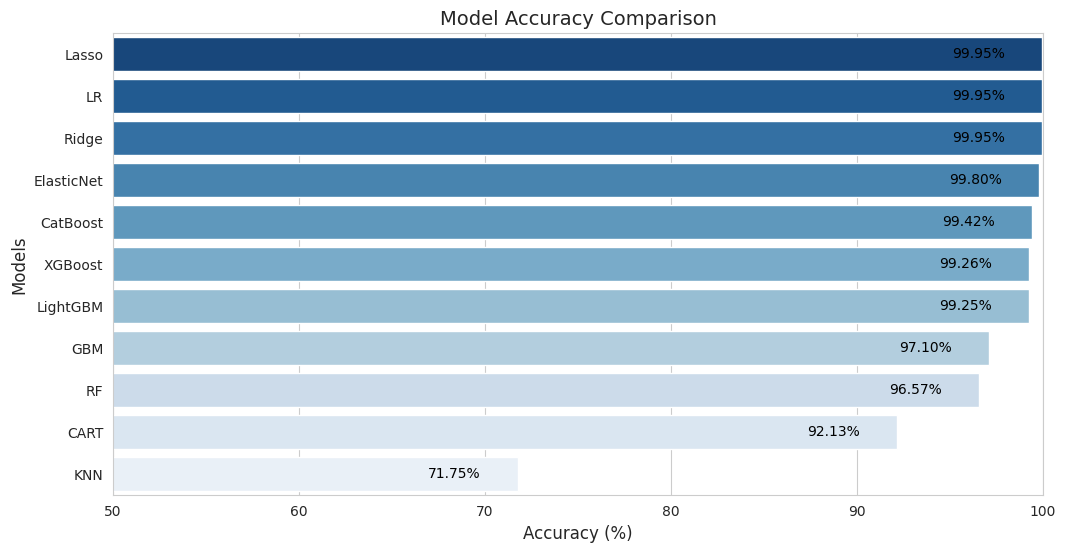

In [53]:
models = ["Lasso", "LR", "Ridge", "ElasticNet", "CatBoost", "XGBoost", 
          "LightGBM", "GBM", "RF", "CART", "KNN"]

r2_scores = [0.9995, 0.9995, 0.9995, 0.9980, 0.9942, 0.9926, 
             0.9925, 0.9710, 0.9657, 0.9213, 0.7175]
accuracy = np.array(r2_scores) * 100
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.barplot(x=accuracy, y=models, palette="Blues_r")
plt.xlabel("Accuracy (%)", fontsize=12)
plt.ylabel("Models", fontsize=12)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlim(50, 100)
for index, value in enumerate(accuracy):
    plt.text(value - 2, index, f"{value:.2f}%", va='center', ha='right', fontsize=10, color="black")

# Show the plot
plt.show()

## Thanks ...pls Upvotes...!!!!